In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from statsmodels.stats.power import TTestIndPower


# Simulation

In [2]:
n_samples = 5
n_simulations = 1000
mu1 = 65
mu2 = 72
s1 = 4
s2 = 3

In [3]:
def simulate_two_gaussians(n_samples, n_simulations=1000, mu1=0, mu2=1, s1=1, s2=1):
    samples_1 = [np.random.normal(loc=mu1, scale=s1, size=n_samples) for i in range(n_simulations )]
    means_1 = np.mean(samples_1, axis=1)
    samples_2 = [np.random.normal(loc=mu2, scale=s2, size=n_samples) for i in range(n_simulations)]
    means_2 = np.mean(samples_2, axis=1)
    
    plt.hist(means_1, bins=50, color="y")
    plt.hist(means_2, bins=50, color="b")

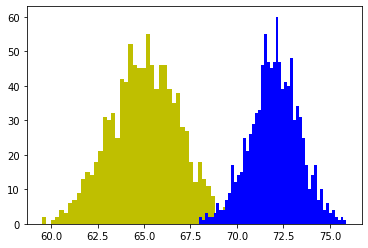

In [4]:
simulate_two_gaussians(n_samples=n_samples, n_simulations=n_simulations, mu1=mu1, mu2=mu2, s1=s1, s2=s2)

# Youtube Business case

In [5]:
prev_yt_data = pd.read_csv("prev_data.csv")

In [6]:
prev_yt_data.head()

,date,customer_id,premium,watch_time_hrs
0,2017-05-23,865,0,4.014356
1,2017-04-27,538,0,2.276858
2,2017-09-06,495,0,4.695549
3,2017-03-15,247,0,1.244982
4,2017-10-25,471,0,2.558311


In [7]:
prev_yt_data.describe()

,customer_id,premium,watch_time_hrs
count,20000.000000,20000.000000,20000.000000
mean,496.860200,0.155450,8.121169
std,287.733041,0.362342,212.138482
min,0.000000,0.000000,0.192767
25%,250.000000,0.000000,1.769474
50%,496.000000,0.000000,2.854844
75%,742.250000,0.000000,4.551919
max,999.000000,1.000000,10008.561895


In [8]:
q998 = prev_yt_data["watch_time_hrs"].quantile(0.998)
q998

23.93426900607841

In [9]:
prev_yt_data_no_out = prev_yt_data[prev_yt_data["watch_time_hrs"]<q998]

In [10]:
prev_yt_data_no_out.describe()

,customer_id,premium,watch_time_hrs
count,19960.000000,19960.000000,19960.000000
mean,496.965180,0.155261,3.578971
std,287.699416,0.362162,2.676111
min,0.000000,0.000000,0.192767
25%,250.000000,0.000000,1.768304
50%,496.000000,0.000000,2.850750
75%,743.000000,0.000000,4.534618
max,999.000000,1.000000,23.933561


In [11]:
mu_h0 = np.mean(prev_yt_data_no_out["watch_time_hrs"])
mu_h0

3.578971070350521

In [12]:
diff_mu = mu_h0 * 0.1
diff_mu

0.3578971070350521

In [13]:
# Effect size: Cohen'd (mu1 - mu2)/sigma
cohens_d_effect_size = diff_mu/np.std(prev_yt_data_no_out["watch_time_hrs"])
cohens_d_effect_size

0.13374109689019192

In [14]:
# We have to setup alpha and power (power = 1 - beta)
# In my A/B test, how many samples should I get for the new model

In [15]:
TTestIndPower().solve_power(effect_size=cohens_d_effect_size, alpha=0.01, power=.90)

/Users/ajay/.pyenv/versions/3.8.12/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/Users/ajay/.pyenv/versions/3.8.12/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6826: RuntimeWarning: invalid value encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)
/Users/ajay/.pyenv/versions/3.8.12/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: overflow encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/Users/ajay/.pyenv/versions/3.8.12/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:6826: RuntimeWarning: overflow encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)


1665.3988798589194